# 03 - Clustering Analysis

This notebook applies unsupervised clustering to identify meaningful population segments based on health and lifestyle indicators.

**Algorithms used:**
1. **K-Means** — partition-based, good for spherical clusters
2. **DBSCAN** — density-based, can find arbitrary-shaped clusters and detect noise

**Goal:** Discover latent health risk profiles that could guide targeted public health campaigns.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Preprocessed Data

In [2]:
# Load full scaled dataset for clustering
X_scaled = pd.read_csv('../data/processed/X_full_scaled.csv')
y_true = pd.read_csv('../data/processed/y_full.csv').squeeze()  # True diabetes labels for evaluation

print(f'Dataset shape: {X_scaled.shape}')
print(f'Features: {list(X_scaled.columns)}')

# Use a sample for some computationally expensive operations
# Full dataset (253k) is too large for silhouette calculation on every k
np.random.seed(42)
sample_size = 20000
sample_idx = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled.iloc[sample_idx].reset_index(drop=True)
y_sample = y_true.iloc[sample_idx].reset_index(drop=True)

print(f'\nSample size for tuning: {sample_size:,}')

Dataset shape: (253680, 21)
Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Sample size for tuning: 20,000


## 2. K-Means Clustering

### 2.1 Finding Optimal k — Elbow Method & Silhouette Score

**Elbow Method**: Plot inertia (within-cluster sum of squares) vs k. The "elbow" point indicates a good trade-off.

**Silhouette Score**: Measures how similar a sample is to its own cluster vs neighboring clusters. Range [-1, 1], higher is better.

In [3]:
# Evaluate K-Means for different values of k
k_range = range(2, 11)
inertias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []

print('Evaluating K-Means for k = 2 to 10 (on sample)...')
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_sample)
    
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_sample, labels)
    cal = calinski_harabasz_score(X_sample, labels)
    dav = davies_bouldin_score(X_sample, labels)
    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)
    
    print(f'  k={k:2d}: Inertia={kmeans.inertia_:>12,.0f}  Silhouette={sil:.4f}  Calinski-Harabasz={cal:>10,.0f}  Davies-Bouldin={dav:.4f}')

print('\nDone.')

Evaluating K-Means for k = 2 to 10 (on sample)...
  k= 2: Inertia=     371,223  Silhouette=0.2044  Calinski-Harabasz=     2,612  Davies-Bouldin=2.5162
  k= 3: Inertia=     350,647  Silhouette=0.0821  Calinski-Harabasz=     1,969  Davies-Bouldin=2.9266
  k= 4: Inertia=     331,564  Silhouette=0.0915  Calinski-Harabasz=     1,772  Davies-Bouldin=2.5646
  k= 5: Inertia=     314,900  Silhouette=0.1006  Calinski-Harabasz=     1,664  Davies-Bouldin=2.3264
  k= 6: Inertia=     302,569  Silhouette=0.1015  Calinski-Harabasz=     1,548  Davies-Bouldin=2.2616
  k= 7: Inertia=     290,390  Silhouette=0.0990  Calinski-Harabasz=     1,484  Davies-Bouldin=2.2123
  k= 8: Inertia=     276,619  Silhouette=0.1053  Calinski-Harabasz=     1,477  Davies-Bouldin=2.0754
  k= 9: Inertia=     268,212  Silhouette=0.0809  Calinski-Harabasz=     1,412  Davies-Bouldin=2.1042
  k=10: Inertia=     256,752  Silhouette=0.0921  Calinski-Harabasz=     1,410  Davies-Bouldin=1.9982

Done.


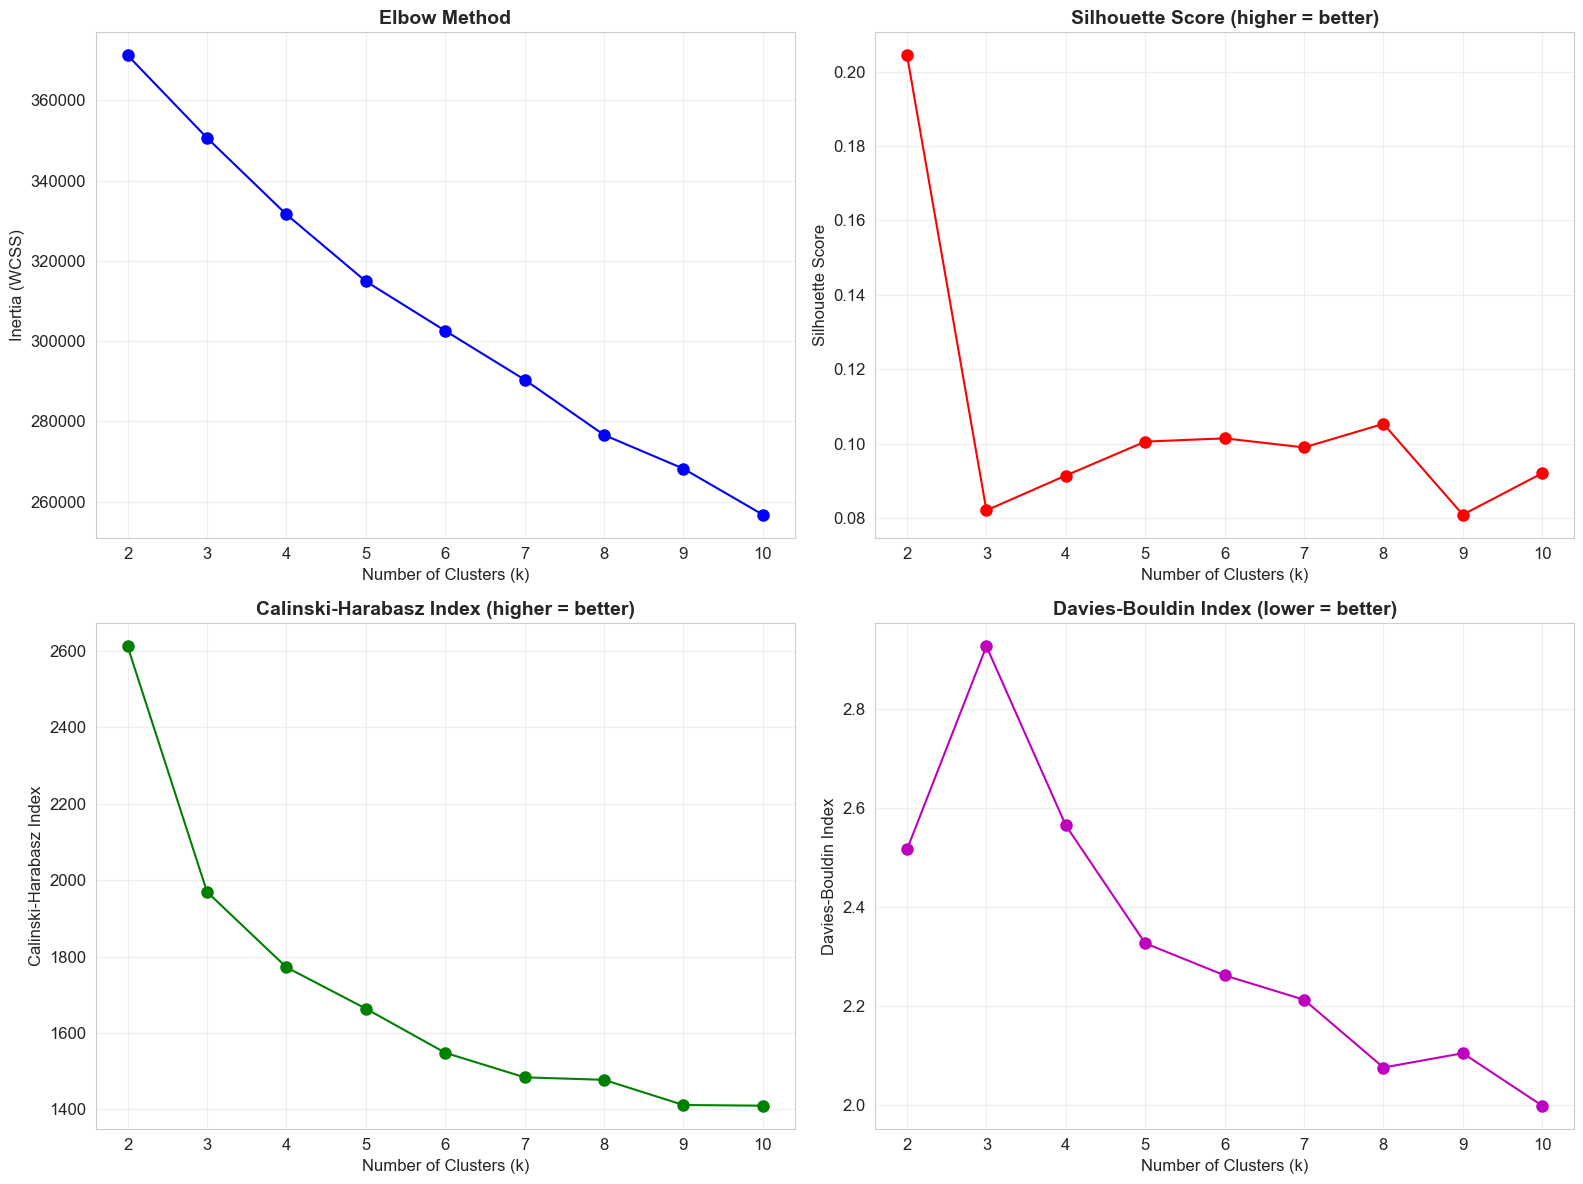

Best k by Silhouette Score: 2 (score=0.2044)


In [4]:
# Plot evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Elbow plot
axes[0, 0].plot(list(k_range), inertias, 'bo-', markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia (WCSS)')
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(list(k_range))
axes[0, 0].grid(True, alpha=0.3)

# Silhouette score
axes[0, 1].plot(list(k_range), silhouette_scores, 'ro-', markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (higher = better)', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(list(k_range))
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz
axes[1, 0].plot(list(k_range), calinski_scores, 'go-', markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Index')
axes[1, 0].set_title('Calinski-Harabasz Index (higher = better)', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(list(k_range))
axes[1, 0].grid(True, alpha=0.3)

# Davies-Bouldin
axes[1, 1].plot(list(k_range), davies_scores, 'mo-', markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin Index')
axes[1, 1].set_title('Davies-Bouldin Index (lower = better)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(list(k_range))
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/kmeans_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Best k by silhouette
best_k_sil = list(k_range)[np.argmax(silhouette_scores)]
print(f'Best k by Silhouette Score: {best_k_sil} (score={max(silhouette_scores):.4f})')

### 2.2 Apply K-Means with Chosen k

Based on the elbow plot and silhouette analysis, we select **k=3** as a reasonable number of clusters. This also aligns with the public health context — we expect to find groups such as "healthy", "at-risk", and "high-risk" populations.

In [5]:
# Apply K-Means with chosen k on full dataset
chosen_k = 3
kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10, max_iter=300)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print(f'K-Means Clustering (k={chosen_k}) on full dataset ({len(X_scaled):,} samples)')
print(f'\nCluster distribution:')
for c in range(chosen_k):
    count = (kmeans_labels == c).sum()
    print(f'  Cluster {c}: {count:>8,} samples ({count/len(kmeans_labels)*100:.1f}%)')

# Evaluate on full dataset
sil_full = silhouette_score(X_scaled, kmeans_labels, sample_size=20000, random_state=42)
cal_full = calinski_harabasz_score(X_scaled, kmeans_labels)
dav_full = davies_bouldin_score(X_scaled, kmeans_labels)

print(f'\nFull-dataset evaluation metrics:')
print(f'  Silhouette Score:       {sil_full:.4f}')
print(f'  Calinski-Harabasz:      {cal_full:,.0f}')
print(f'  Davies-Bouldin:         {dav_full:.4f}')

K-Means Clustering (k=3) on full dataset (253,680 samples)

Cluster distribution:
  Cluster 0:  177,593 samples (70.0%)
  Cluster 1:   63,719 samples (25.1%)
  Cluster 2:   12,368 samples (4.9%)

Full-dataset evaluation metrics:
  Silhouette Score:       0.2040
  Calinski-Harabasz:      24,454
  Davies-Bouldin:         2.2548


### 2.2b Silhouette Blade Plot

The silhouette blade plot shows the silhouette coefficient for **every sample**, grouped by cluster. A wide, uniform blade indicates a well-separated cluster; thin or negative-extending blades indicate overlap.

In [ ]:
# Silhouette blade plot for K-Means (k=3) on a sample for clarity
from sklearn.metrics import silhouette_samples

# Compute silhouette values per sample (on sample for performance)
km_sample_labels_blade = kmeans_final.predict(X_sample)
sample_silhouette_vals = silhouette_samples(X_sample, km_sample_labels_blade)
avg_silhouette = np.mean(sample_silhouette_vals)

fig, ax = plt.subplots(figsize=(10, 8))
y_lower = 10

for i in range(chosen_k):
    # Silhouette values for cluster i, sorted
    cluster_sil = sample_silhouette_vals[km_sample_labels_blade == i]
    cluster_sil.sort()
    
    cluster_size = len(cluster_sil)
    y_upper = y_lower + cluster_size
    
    color = plt.cm.Set2(i / chosen_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=color, edgecolor=color, alpha=0.8)
    
    # Label the cluster
    ax.text(-0.05, y_lower + 0.5 * cluster_size, f'Cluster {i}',
            fontsize=12, fontweight='bold', va='center')
    
    y_lower = y_upper + 10  # gap between clusters

# Average silhouette line
ax.axvline(x=avg_silhouette, color='red', linestyle='--', linewidth=2,
           label=f'Average Silhouette = {avg_silhouette:.4f}')

ax.set_xlabel('Silhouette Coefficient', fontsize=13)
ax.set_ylabel('Samples (sorted within each cluster)', fontsize=13)
ax.set_title(f'Silhouette Blade Plot — K-Means (k={chosen_k})', fontsize=15, fontweight='bold')
ax.set_yticks([])
ax.set_xlim([-0.15, 0.6])
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/kmeans_silhouette_blade.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-cluster stats
print(f'\nPer-cluster silhouette statistics:')
for i in range(chosen_k):
    vals = sample_silhouette_vals[km_sample_labels_blade == i]
    neg_pct = (vals < 0).sum() / len(vals) * 100
    print(f'  Cluster {i}: mean={vals.mean():.4f}, min={vals.min():.4f}, '
          f'max={vals.max():.4f}, negative={neg_pct:.1f}%')

### 2.3 Visualise K-Means Clusters (PCA 2D)

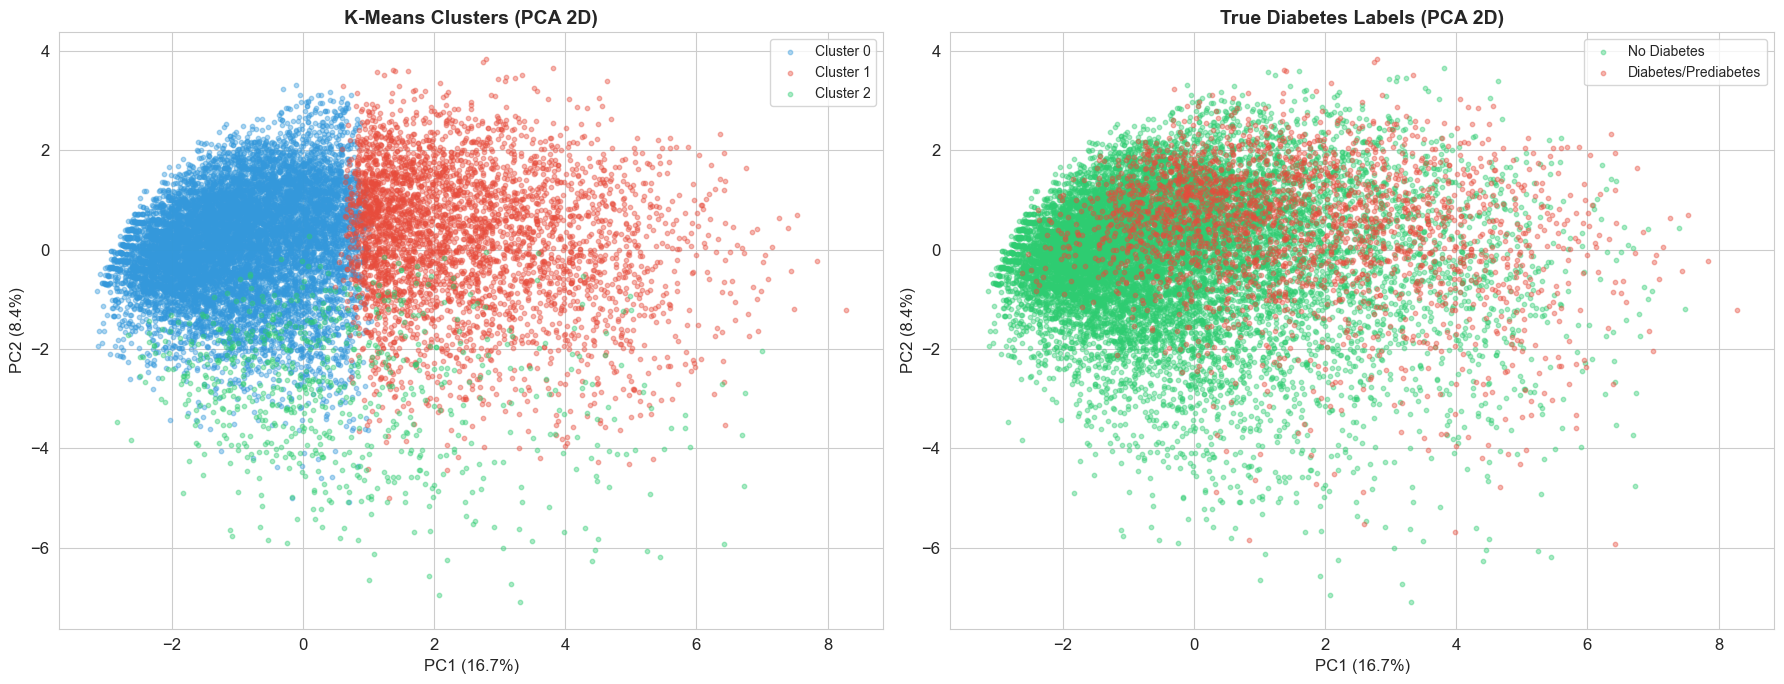

In [6]:
# PCA for 2D visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters vs true labels side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Use a sample for clearer visualisation
np.random.seed(42)
vis_idx = np.random.choice(len(X_pca), size=15000, replace=False)

# K-Means clusters
cluster_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
for c in range(chosen_k):
    mask = kmeans_labels[vis_idx] == c
    axes[0].scatter(X_pca[vis_idx][mask, 0], X_pca[vis_idx][mask, 1],
                   c=cluster_colors[c], label=f'Cluster {c}', alpha=0.4, s=10)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('K-Means Clusters (PCA 2D)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)

# True diabetes labels for comparison
true_colors = {0: '#2ecc71', 1: '#e74c3c'}
true_labels_map = {0: 'No Diabetes', 1: 'Diabetes/Prediabetes'}
for cls in [0, 1]:
    mask = y_true.values[vis_idx] == cls
    axes[1].scatter(X_pca[vis_idx][mask, 0], X_pca[vis_idx][mask, 1],
                   c=true_colors[cls], label=true_labels_map[cls], alpha=0.4, s=10)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('True Diabetes Labels (PCA 2D)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../notebooks/figures/kmeans_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Interpret K-Means Clusters — Cluster Profiling

To understand **what each cluster represents**, we examine the mean feature values per cluster and compare the diabetes rate.

In [7]:
# Load original (unscaled) data for interpretable profiling
df_original = pd.read_csv('../data/CDC Diabetes Dataset.csv')
df_original['Diabetes_binary'] = (df_original['Diabetes_012'] > 0).astype(int)
df_original['KMeans_Cluster'] = kmeans_labels

# Feature means per cluster (original scale for interpretability)
feature_cols = [c for c in df_original.columns if c not in ['Diabetes_012', 'Diabetes_binary', 'KMeans_Cluster']]
cluster_profiles = df_original.groupby('KMeans_Cluster')[feature_cols].mean().round(3)

print('=== K-Means Cluster Profiles (Mean Feature Values) ===')
print(cluster_profiles.T.to_string())

# Diabetes rate per cluster
print('\n=== Diabetes Rate per Cluster ===')
for c in range(chosen_k):
    cluster_data = df_original[df_original['KMeans_Cluster'] == c]
    diabetes_rate = cluster_data['Diabetes_binary'].mean() * 100
    size = len(cluster_data)
    print(f'  Cluster {c}: {size:>8,} people | Diabetes rate: {diabetes_rate:.1f}%')

=== K-Means Cluster Profiles (Mean Feature Values) ===
KMeans_Cluster             0       1       2
HighBP                 0.326   0.733   0.343
HighChol               0.354   0.638   0.330
CholCheck              0.962   0.985   0.864
BMI                   27.439  30.911  28.898
Smoker                 0.381   0.607   0.494
Stroke                 0.010   0.129   0.030
HeartDiseaseorAttack   0.032   0.273   0.067
PhysActivity           0.855   0.495   0.691
Fruits                 0.671   0.544   0.568
Veggies                0.856   0.698   0.761
HvyAlcoholConsump      0.063   0.035   0.067
AnyHealthcare          1.000   0.999   0.000
NoDocbcCost            0.043   0.144   0.370
GenHlth                2.110   3.594   2.696
MentHlth               1.688   7.030   4.869
PhysHlth               1.303  12.388   4.468
DiffWalk               0.022   0.579   0.153
Sex                    0.454   0.393   0.484
Age                    7.638   9.495   6.158
Education              5.294   4.475   4.520


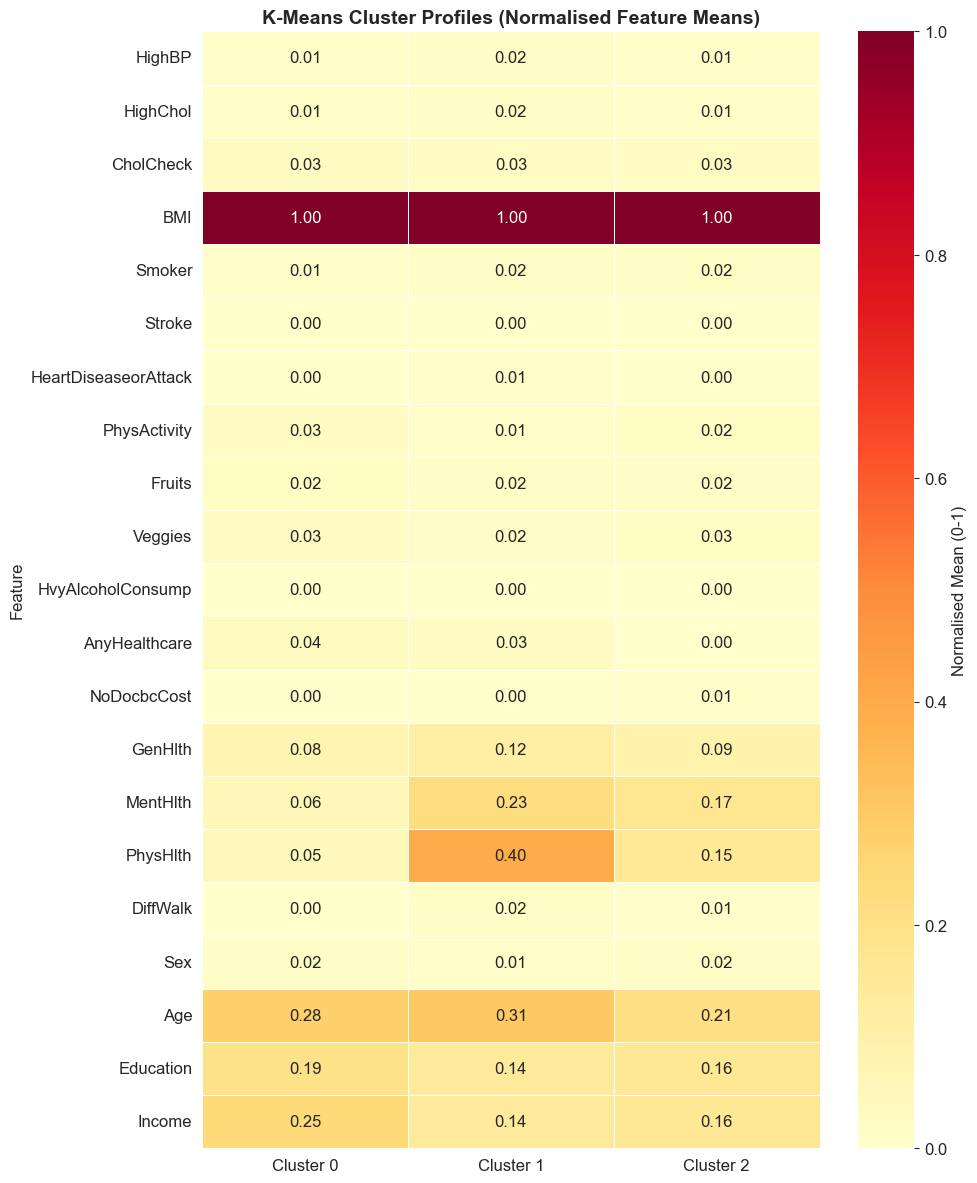

In [8]:
# Visualise cluster profiles — heatmap of normalised feature means
from sklearn.preprocessing import MinMaxScaler

# Normalise profiles to [0, 1] for better heatmap comparison
scaler_viz = MinMaxScaler()
profiles_normalised = pd.DataFrame(
    scaler_viz.fit_transform(cluster_profiles.T),
    index=cluster_profiles.columns,
    columns=[f'Cluster {c}' for c in range(chosen_k)]
)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(profiles_normalised, annot=True, fmt='.2f', cmap='YlOrRd',
           linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalised Mean (0-1)'})
ax.set_title('K-Means Cluster Profiles (Normalised Feature Means)', fontsize=14, fontweight='bold')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig('../notebooks/figures/kmeans_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

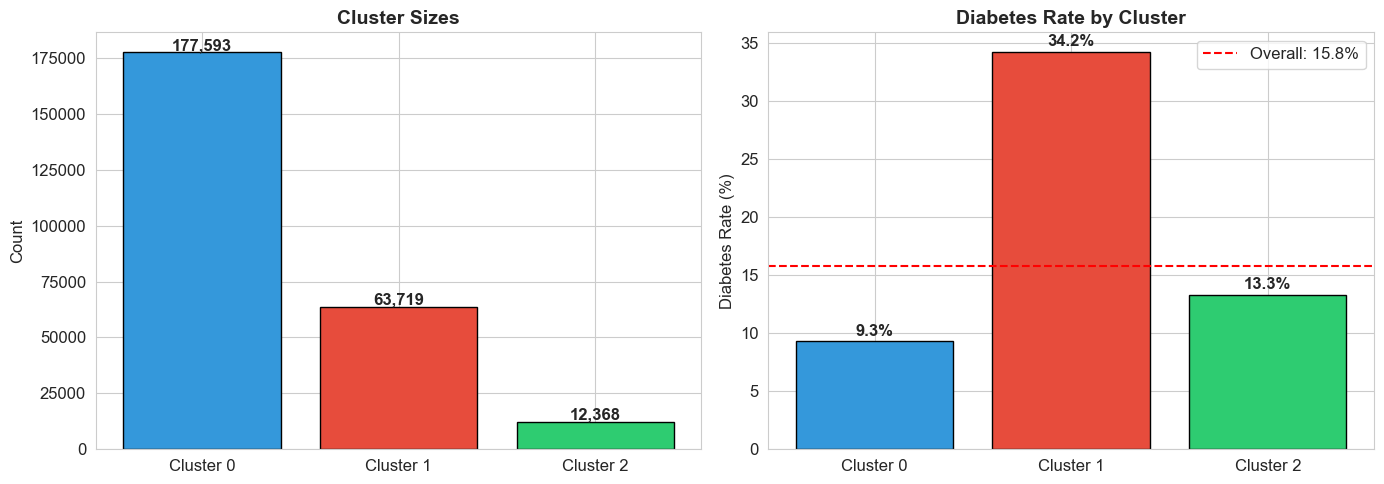

In [9]:
# Diabetes rate comparison across clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster sizes
cluster_sizes = df_original['KMeans_Cluster'].value_counts().sort_index()
axes[0].bar([f'Cluster {c}' for c in range(chosen_k)], cluster_sizes.values,
           color=cluster_colors[:chosen_k], edgecolor='black')
axes[0].set_title('Cluster Sizes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(cluster_sizes.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Diabetes rate per cluster
diabetes_rates = [df_original[df_original['KMeans_Cluster'] == c]['Diabetes_binary'].mean() * 100
                 for c in range(chosen_k)]
bars = axes[1].bar([f'Cluster {c}' for c in range(chosen_k)], diabetes_rates,
                  color=cluster_colors[:chosen_k], edgecolor='black')
axes[1].set_title('Diabetes Rate by Cluster', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].axhline(y=df_original['Diabetes_binary'].mean()*100, color='red',
               linestyle='--', label=f'Overall: {df_original["Diabetes_binary"].mean()*100:.1f}%')
axes[1].legend()
for i, v in enumerate(diabetes_rates):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/kmeans_diabetes_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based algorithm that:
- Does **not** require specifying k in advance
- Can find **arbitrary-shaped** clusters
- Identifies **noise points** (outliers)

**Key parameters:**
- `eps`: Maximum distance between two points to be considered neighbors
- `min_samples`: Minimum points to form a dense region (core point)

### 3.1 Finding Optimal eps — k-Distance Plot

Using k=42 for k-distance plot (heuristic: 2 * n_features)


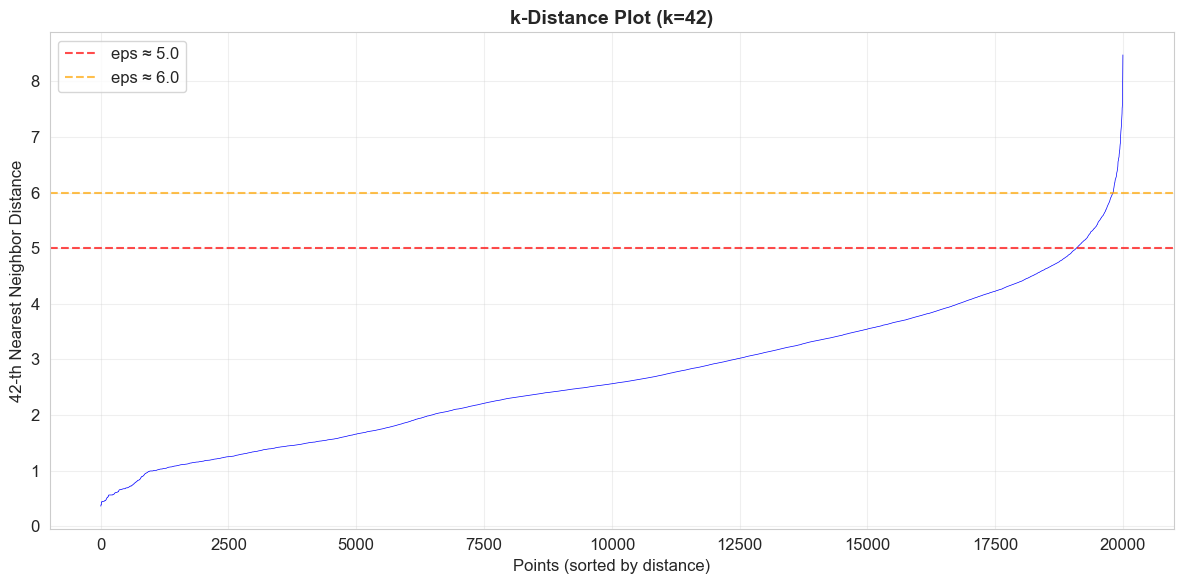


Distance statistics: min=0.36, median=2.56, mean=2.70, max=8.48


In [10]:
# k-distance plot to find optimal eps
# Use k = 2 * n_features - 1 as a heuristic for min_samples
k_neighbors = 2 * X_sample.shape[1]  # 2 * 21 = 42
print(f'Using k={k_neighbors} for k-distance plot (heuristic: 2 * n_features)')

nn = NearestNeighbors(n_neighbors=k_neighbors)
nn.fit(X_sample)
distances, indices = nn.kneighbors(X_sample)

# Sort the k-th nearest neighbor distance
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(k_distances)), k_distances, 'b-', linewidth=0.5)
ax.set_xlabel('Points (sorted by distance)', fontsize=12)
ax.set_ylabel(f'{k_neighbors}-th Nearest Neighbor Distance', fontsize=12)
ax.set_title(f'k-Distance Plot (k={k_neighbors})', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Mark potential elbow region
ax.axhline(y=5.0, color='red', linestyle='--', alpha=0.7, label='eps ≈ 5.0')
ax.axhline(y=6.0, color='orange', linestyle='--', alpha=0.7, label='eps ≈ 6.0')
ax.legend()

plt.tight_layout()
plt.savefig('../notebooks/figures/dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDistance statistics: min={k_distances.min():.2f}, median={np.median(k_distances):.2f}, '
      f'mean={k_distances.mean():.2f}, max={k_distances.max():.2f}')

In [11]:
# Try multiple DBSCAN configurations on sample
eps_values = [4.0, 4.5, 5.0, 5.5, 6.0]
min_samples_values = [20, 30, 42]

print(f'{"eps":>6s} {"min_samples":>12s} {"Clusters":>10s} {"Noise":>10s} {"Noise%":>8s} {"Silhouette":>12s}')
print('-' * 65)

dbscan_results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        db_labels = db.fit_predict(X_sample)
        
        n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        n_noise = (db_labels == -1).sum()
        noise_pct = n_noise / len(db_labels) * 100
        
        # Silhouette only if more than 1 cluster and not all noise
        if n_clusters >= 2 and n_noise < len(db_labels) - 1:
            non_noise_mask = db_labels != -1
            sil = silhouette_score(X_sample[non_noise_mask], db_labels[non_noise_mask])
        else:
            sil = float('nan')
        
        dbscan_results.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters,
                               'n_noise': n_noise, 'noise_pct': noise_pct, 'silhouette': sil})
        print(f'{eps:6.1f} {ms:12d} {n_clusters:10d} {n_noise:10,} {noise_pct:7.1f}% {sil:12.4f}')

dbscan_results_df = pd.DataFrame(dbscan_results)
print(f'\nBest by silhouette (if valid):')
valid = dbscan_results_df[dbscan_results_df['silhouette'].notna() & (dbscan_results_df['n_clusters'] >= 2)]
if len(valid) > 0:
    best = valid.loc[valid['silhouette'].idxmax()]
    print(f"  eps={best['eps']}, min_samples={best['min_samples']}, "
          f"clusters={best['n_clusters']}, silhouette={best['silhouette']:.4f}")

   eps  min_samples   Clusters      Noise   Noise%   Silhouette
-----------------------------------------------------------------
   4.0           20          7        802     4.0%       0.2143
   4.0           30          6      1,031     5.2%       0.2147
   4.0           42          5      1,272     6.4%       0.2192
   4.5           20          5        342     1.7%       0.2460
   4.5           30          5        439     2.2%       0.2445
   4.5           42          5        538     2.7%       0.2419
   5.0           20          3        138     0.7%       0.2575
   5.0           30          3        167     0.8%       0.2578
   5.0           42          3        202     1.0%       0.2563
   5.5           20          1         48     0.2%          nan
   5.5           30          1         62     0.3%          nan
   5.5           42          1         73     0.4%          nan
   6.0           20          1         18     0.1%          nan
   6.0           30          1        

### 3.2 Apply DBSCAN with Chosen Parameters

In [12]:
# Apply DBSCAN with selected parameters on sample
# Choose eps and min_samples based on the k-distance plot and parameter search above
chosen_eps = 5.0
chosen_min_samples = 30

dbscan_final = DBSCAN(eps=chosen_eps, min_samples=chosen_min_samples)
dbscan_labels = dbscan_final.fit_predict(X_sample)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = (dbscan_labels == -1).sum()

print(f'DBSCAN Results (eps={chosen_eps}, min_samples={chosen_min_samples}):')
print(f'  Number of clusters: {n_clusters_db}')
print(f'  Noise points: {n_noise_db:,} ({n_noise_db/len(dbscan_labels)*100:.1f}%)')
print(f'\nCluster distribution:')
for c in sorted(set(dbscan_labels)):
    count = (dbscan_labels == c).sum()
    label_name = 'Noise' if c == -1 else f'Cluster {c}'
    print(f'  {label_name:12s}: {count:>6,} samples ({count/len(dbscan_labels)*100:.1f}%)')

# Silhouette (excluding noise)
if n_clusters_db >= 2:
    non_noise = dbscan_labels != -1
    sil_db = silhouette_score(X_sample[non_noise], dbscan_labels[non_noise])
    print(f'\n  Silhouette Score (excl. noise): {sil_db:.4f}')

DBSCAN Results (eps=5.0, min_samples=30):
  Number of clusters: 3
  Noise points: 167 (0.8%)

Cluster distribution:
  Noise       :    167 samples (0.8%)
  Cluster 0   : 18,384 samples (91.9%)
  Cluster 1   :    743 samples (3.7%)
  Cluster 2   :    706 samples (3.5%)

  Silhouette Score (excl. noise): 0.2578


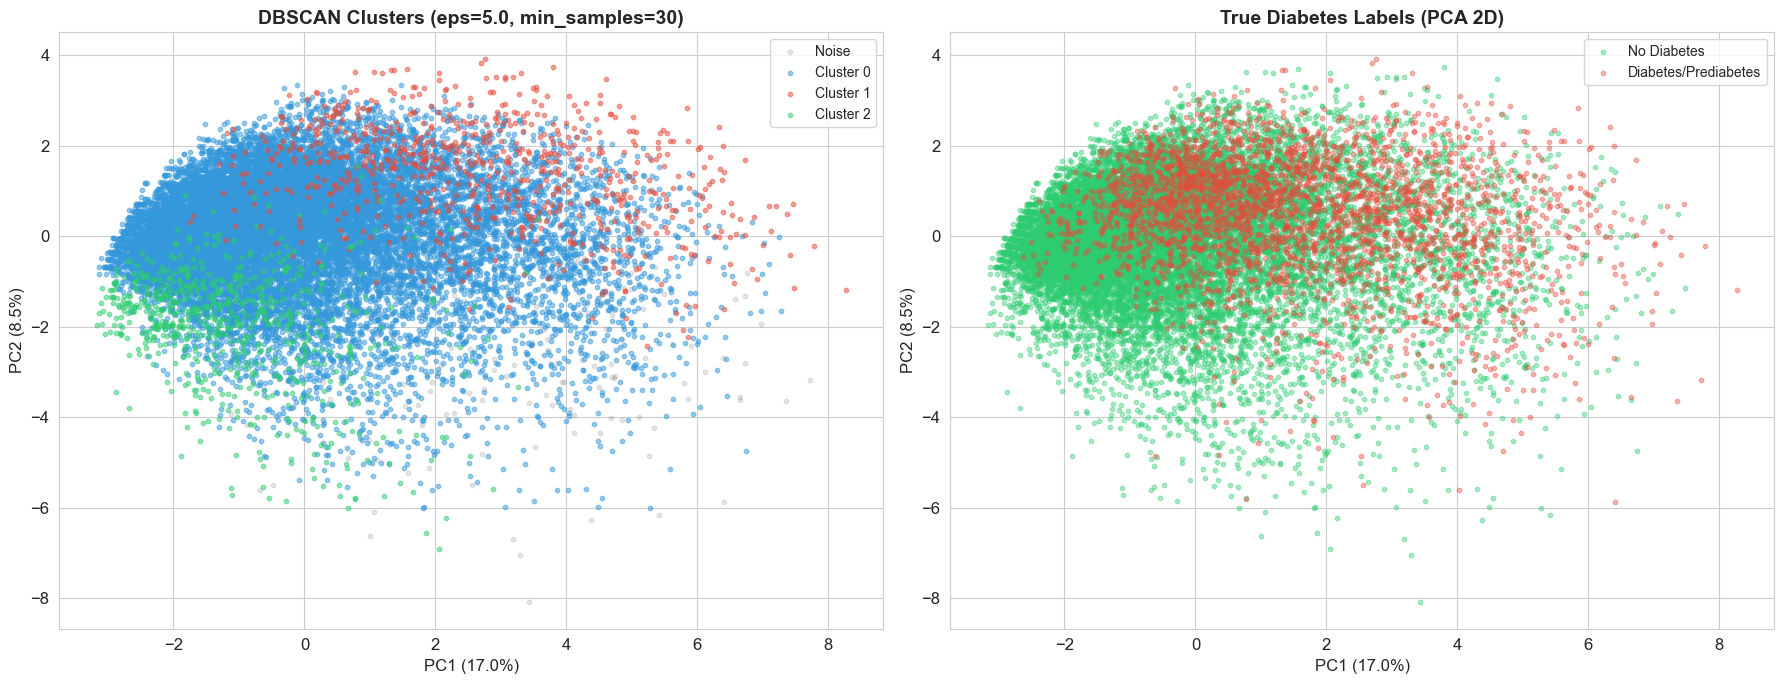

In [13]:
# Visualise DBSCAN clusters using PCA 2D (on sample)
pca_sample = PCA(n_components=2, random_state=42)
X_sample_pca = pca_sample.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# DBSCAN clusters
unique_labels = sorted(set(dbscan_labels))
colors_db = ['gray'] + cluster_colors[:n_clusters_db]  # gray for noise (-1)
for i, c in enumerate(unique_labels):
    mask = dbscan_labels == c
    label_name = 'Noise' if c == -1 else f'Cluster {c}'
    alpha = 0.2 if c == -1 else 0.5
    axes[0].scatter(X_sample_pca[mask, 0], X_sample_pca[mask, 1],
                   c=colors_db[i], label=label_name, alpha=alpha, s=10)
axes[0].set_xlabel(f'PC1 ({pca_sample.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_sample.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'DBSCAN Clusters (eps={chosen_eps}, min_samples={chosen_min_samples})',
                 fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)

# True labels for comparison
for cls in [0, 1]:
    mask = y_sample.values == cls
    axes[1].scatter(X_sample_pca[mask, 0], X_sample_pca[mask, 1],
                   c=true_colors[cls], label=true_labels_map[cls], alpha=0.4, s=10)
axes[1].set_xlabel(f'PC1 ({pca_sample.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_sample.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('True Diabetes Labels (PCA 2D)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../notebooks/figures/dbscan_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. K-Means vs DBSCAN Comparison

In [14]:
# Summary comparison table
print('=' * 70)
print('CLUSTERING ALGORITHM COMPARISON')
print('=' * 70)
print(f'{"Metric":30s} {"K-Means (k=" + str(chosen_k) + ")":>20s} {"DBSCAN":>15s}')
print('-' * 70)

# K-Means metrics (on sample for fair comparison)
km_sample_labels = kmeans_final.predict(X_sample)
sil_km_sample = silhouette_score(X_sample, km_sample_labels)

print(f'{"Number of clusters":30s} {chosen_k:>20d} {n_clusters_db:>15d}')
print(f'{"Noise points":30s} {"N/A":>20s} {n_noise_db:>15,}')

if n_clusters_db >= 2:
    print(f'{"Silhouette Score":30s} {sil_km_sample:>20.4f} {sil_db:>15.4f}')

print(f'{"Requires k?":30s} {"Yes":>20s} {"No":>15s}')
print(f'{"Handles noise?":30s} {"No":>20s} {"Yes":>15s}')
print(f'{"Cluster shape":30s} {"Spherical":>20s} {"Arbitrary":>15s}')
print(f'{"Scalability":30s} {"Good":>20s} {"Moderate":>15s}')
print('=' * 70)

print('\n📌 K-Means is preferred here because:')
print('   - The data has high overlap between classes (as shown in EDA PCA plot)')
print('   - K-Means provides clear, interpretable cluster centroids')
print('   - DBSCAN may produce too many noise points in high-dimensional space')
print('   - K-Means cluster profiles directly inform public health interventions')

CLUSTERING ALGORITHM COMPARISON
Metric                                K-Means (k=3)          DBSCAN
----------------------------------------------------------------------
Number of clusters                                3               3
Noise points                                    N/A             167
Silhouette Score                             0.2040          0.2578
Requires k?                                     Yes              No
Handles noise?                                   No             Yes
Cluster shape                             Spherical       Arbitrary
Scalability                                    Good        Moderate

📌 K-Means is preferred here because:
   - The data has high overlap between classes (as shown in EDA PCA plot)
   - K-Means provides clear, interpretable cluster centroids
   - DBSCAN may produce too many noise points in high-dimensional space
   - K-Means cluster profiles directly inform public health interventions


## 5. Clustering Summary & Interpretation

### Key Findings:

**K-Means (k=3) identified three distinct population segments:**

| Cluster | Profile | Size | Diabetes Rate | Key Characteristics |
|---------|---------|------|--------------|---------------------|
| Cluster 0 | **Healthy / Low-risk** | 177,593 (70%) | **9.3%** | Low BP/cholesterol, high physical activity, high fruit & veg intake, young, high income/education |
| Cluster 1 | **High-risk / Chronic** | 63,719 (25%) | **34.2%** | High BP (73%), high cholesterol (64%), high BMI (31), highest stroke/heart disease, poor general health, oldest age, low income |
| Cluster 2 | **Uninsured / At-risk** | 12,368 (5%) | **13.3%** | No healthcare (0%), high out-of-pocket costs (37%), youngest group, moderate smoking, lower education |

### Public Health Implications:
- **Cluster 1** (34.2% diabetes rate, 2× the overall rate) → Priority target for diabetes management & cardiovascular screening
- **Cluster 2** (no healthcare access) → Needs outreach programs & subsidised screening
- **Cluster 0** (low risk) → Maintain through prevention & awareness campaigns

### Evaluation:
- **Silhouette scores are moderate** (~0.20 for K-Means, ~0.26 for DBSCAN) — expected given the high overlap seen in EDA's PCA plot
- **DBSCAN** found 3 clusters at eps=5.0 with slightly better silhouette, but 92% of data in one cluster (less useful)
- **K-Means** provides more balanced, interpretable clusters → preferred for this application

### Limitations:
- K-Means assumes spherical clusters and is sensitive to outliers
- High dimensionality (21 features) contributes to the "curse of dimensionality"
- DBSCAN struggled to produce balanced clusters in this high-dimensional space
- Cluster interpretation requires domain expertise in public health